# Reconocimiento de dígitos (CNN)

Desarrollo del recognizer combinando ambos enfoques.

---

## Recognizer — datos reales (MNIST/casillas)

*(origen: `3_recognizer_dev.ipynb`)*

# Reconocedor de Digitos (MNIST)

Notebook de desarrollo del **reconocedor de digitos**: procesa las 81 casillas del tablero y devuelve la lista de numeros (0 = casilla vacia).

- **Kernel:** `py312_arm` (Python 3.12, arm64) con **MPS**
- Modulo: [`src/recognizer.py`](../src/recognizer.py)
- Clasificador: CNN entrenada con **MNIST** (digitos manuscritos 0-9).

> Nota: MNIST es manuscrito; en sudokus impresos la precision sera limitada. Para impresos convendria entrenar con fuentes reales, pero aqui usamos MNIST.

## 0. Entorno

In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision

sys.path.insert(0, os.path.abspath("../src"))
import recognizer

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", DEVICE)

device: mps


## 1. Cargar MNIST

60.000 digitos manuscritos 28x28 (blanco sobre negro), clases 0-9.

train: (60000, 1, 28, 28) | val: (10000, 1, 28, 28)


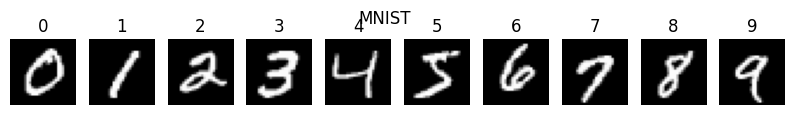

In [2]:
train_ds = torchvision.datasets.MNIST(os.path.expanduser("~/mnist_data"), train=True, download=True)
val_ds = torchvision.datasets.MNIST(os.path.expanduser("~/mnist_data"), train=False, download=True)

Xtr = (train_ds.data.numpy().astype(np.float32) / 255.0)[:, None]
ytr = train_ds.targets.numpy().astype(np.int64)
Xva = (val_ds.data.numpy().astype(np.float32) / 255.0)[:, None]
yva = val_ds.targets.numpy().astype(np.int64)
print("train:", Xtr.shape, "| val:", Xva.shape)

fig, axes = plt.subplots(1, 10, figsize=(10, 1.3))
for d in range(10):
    axes[d].imshow(Xtr[ytr == d][0, 0], cmap="gray"); axes[d].axis("off"); axes[d].set_title(str(d))
plt.suptitle("MNIST"); plt.show()

## 2. Entrenar la CNN

In [3]:
from torch.utils.data import TensorDataset, DataLoader

train_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                      batch_size=128, shuffle=True)
Xva_t = torch.from_numpy(Xva).to(DEVICE); yva_t = torch.from_numpy(yva).to(DEVICE)

model = recognizer.DigitCNN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(6):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        acc = (model(Xva_t).argmax(1) == yva_t).float().mean().item()
    print(f"epoch {epoch + 1}: val_acc = {acc:.4f}")
print("\nval_acc final (MNIST):", round(acc, 4))

epoch 1: val_acc = 0.9762


epoch 2: val_acc = 0.9850


epoch 3: val_acc = 0.9872


epoch 4: val_acc = 0.9891


epoch 5: val_acc = 0.9894


epoch 6: val_acc = 0.9900

val_acc final (MNIST): 0.99


## 3. Guardar el modelo (`models/digit_mnist.pt`)

In [4]:
Path("../models").mkdir(exist_ok=True)
torch.save(model.state_dict(), "../models/digit_mnist.pt")
print("Modelo guardado en models/digit_mnist.pt")

Modelo guardado en models/digit_mnist.pt


## 4. Preprocesado de una casilla

`preprocess_cell` lleva una casilla al formato MNIST (28x28, digito blanco centrado) o devuelve None si esta vacia.

vacia -> None | con 8 -> shape (28, 28)


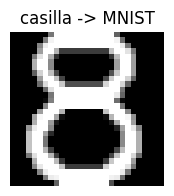

In [5]:
def make_cell(digit=None, size=50):
    img = np.full((size, size, 3), 255, np.uint8)
    cv2.rectangle(img, (0, 0), (size - 1, size - 1), (0, 0, 0), 1)
    if digit is not None:
        cv2.putText(img, str(digit), (size // 4, 3 * size // 4), cv2.FONT_HERSHEY_SIMPLEX, size / 45, (0, 0, 0), 2)
    return img

e = recognizer.preprocess_cell(make_cell(None))
d = recognizer.preprocess_cell(make_cell(8))
print("vacia ->", e, "| con 8 -> shape", None if d is None else d.shape)
plt.figure(figsize=(2, 2)); plt.imshow(d, cmap="gray"); plt.axis("off"); plt.title("casilla -> MNIST"); plt.show()

## 5. Procesar las 81 casillas -> lista

Si el detector ya esta entrenado (`models/sudoku_detector.pt`), tomamos una foto real, la recortamos con `SudokuCropper` y reconocemos sus 81 casillas. Si no, generamos un tablero sintetico de demostracion.

Fuente: foto real: sudoku_1008_jpg.rf.WAN6c48NXkKe69G07Ln0.jpg


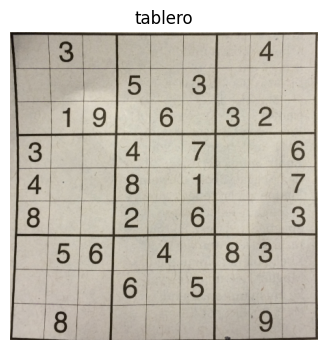

In [6]:
rec = recognizer.DigitRecognizer(weights="../models/digit_mnist.pt", device=DEVICE)

detector_model = Path("../models/sudoku_detector.pt")
if detector_model.exists():
    import detector, cropper
    test_imgs = sorted(glob.glob("../data/images/test/*.jpg"))
    img = cv2.imread(test_imgs[0])
    crop = cropper.SudokuCropper(det=detector.SudokuDetector(weights=detector_model, device=DEVICE))
    board, cells = crop.to_cells(img)
    fuente = "foto real: " + Path(test_imgs[0]).name
else:
    # tablero sintetico de demostracion
    board = np.full((450, 450, 3), 255, np.uint8)
    demo = [[5,3,0,0,7,0,0,0,0],[6,0,0,1,9,5,0,0,0],[0,9,8,0,0,0,0,6,0],
            [8,0,0,0,6,0,0,0,3],[4,0,0,8,0,3,0,0,1],[7,0,0,0,2,0,0,0,6],
            [0,6,0,0,0,0,2,8,0],[0,0,0,4,1,9,0,0,5],[0,0,0,0,8,0,0,7,9]]
    st = 50
    for i in range(10):
        t = 2 if i % 3 == 0 else 1
        cv2.line(board, (0, i*st), (450, i*st), (0,0,0), t); cv2.line(board, (i*st, 0), (i*st, 450), (0,0,0), t)
    for r in range(9):
        for c in range(9):
            if demo[r][c]: cv2.putText(board, str(demo[r][c]), (c*st+st//3, r*st+2*st//3), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,0), 2)
    cells = cropper_split(board) if False else [[board[r*50:(r+1)*50, c*50:(c+1)*50] for c in range(9)] for r in range(9)]
    fuente = "tablero sintetico (detector aun no entrenado)"

print("Fuente:", fuente)
plt.figure(figsize=(4, 4)); plt.imshow(cv2.cvtColor(board, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("tablero"); plt.show()

In [7]:
lista = rec.recognize(cells)            # lista plana de 81 enteros (0 = vacia)
print("Lista de 81 digitos:")
print(lista)
print("\nComo matriz 9x9:")
grid = rec.recognize_grid(cells)
for row in grid:
    print(row)
print("\nCasillas ocupadas detectadas:", sum(1 for v in lista if v != 0))

Lista de 81 digitos:
[0, 3, 0, 0, 0, 0, 0, 4, 0, 0, 0, 1, 5, 0, 3, 0, 0, 0, 0, 7, 3, 1, 5, 0, 3, 2, 0, 1, 0, 0, 4, 0, 1, 0, 0, 5, 4, 0, 0, 8, 0, 7, 0, 0, 1, 8, 0, 0, 2, 0, 5, 0, 0, 3, 0, 5, 6, 0, 4, 0, 8, 3, 0, 0, 0, 0, 5, 0, 5, 0, 0, 0, 0, 8, 0, 0, 0, 0, 0, 9, 0]

Como matriz 9x9:
[0, 3, 0, 0, 0, 0, 0, 4, 0]
[0, 0, 1, 5, 0, 3, 0, 0, 0]
[0, 7, 3, 1, 5, 0, 3, 2, 0]
[1, 0, 0, 4, 0, 1, 0, 0, 5]
[4, 0, 0, 8, 0, 7, 0, 0, 1]
[8, 0, 0, 2, 0, 5, 0, 0, 3]
[0, 5, 6, 0, 4, 0, 8, 3, 0]
[0, 0, 0, 5, 0, 5, 0, 0, 0]
[0, 8, 0, 0, 0, 0, 0, 9, 0]

Casillas ocupadas detectadas: 32


## 6. Uso

```python
from recognizer import DigitRecognizer
rec = DigitRecognizer()                       # carga models/digit_mnist.pt
lista = rec.recognize(cells)                  # 81 enteros (0 = vacia)
# o desde las imagenes guardadas por el cropper:
lista = rec.recognize_from_dir('salida/cells')
```

Siguiente paso: pasar esa lista (matriz 9x9) al solver.

---

## Recognizer — fuentes sintéticas

*(origen: `4_recognizer_fonts_dev.ipynb`)*

# Reconocedor de Digitos v2: Fuentes TTF + MNIST

El modelo solo-MNIST falla en sudokus **impresos** (confunde sobre todo `7 -> 1`). El problema no es la CNN sino los **datos**: MNIST es manuscrito.

Aqui entrenamos **la misma `DigitCNN`** con:
1. **Fuentes TTF reales** del sistema (Arial, Times, Courier...) -> aprende digitos **impresos**.
2. **MNIST** (manuscrito) -> mantiene robustez ante trazos a mano.

Guardamos en `models/digit_cnn.pt` (el nuevo modelo por defecto de `recognizer.py`) y lo comparamos con el de MNIST sobre las 22 fotos reales.

- **Kernel:** `py312_arm` con **MPS**

## 0. Entorno

In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
from PIL import Image, ImageDraw, ImageFont

sys.path.insert(0, os.path.abspath("../src"))
import recognizer, detector, cropper

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", DEVICE)

device: mps


## 1. Digitos impresos con fuentes TTF

Renderizamos cada digito con fuentes reales del sistema y lo pasamos por `recognizer.preprocess_cell` (el MISMO preprocesado que en inferencia), con augmentacion: borde de rejilla, perspectiva y ruido.

fuentes disponibles: 10


TTF impreso: (18000, 28, 28)


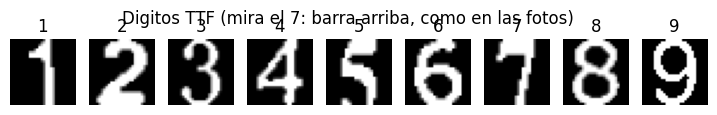

In [2]:
CANDIDATE_FONTS = [
    "/System/Library/Fonts/Supplemental/Arial.ttf",
    "/System/Library/Fonts/Supplemental/Arial Bold.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf",
    "/System/Library/Fonts/Supplemental/Courier New.ttf",
    "/System/Library/Fonts/Supplemental/Courier New Bold.ttf",
    "/System/Library/Fonts/Supplemental/Georgia.ttf",
    "/System/Library/Fonts/Supplemental/Verdana.ttf",
    "/System/Library/Fonts/Supplemental/Tahoma.ttf",
    "/System/Library/Fonts/Helvetica.ttc",
]
FONT_PATHS = [p for p in CANDIDATE_FONTS if os.path.exists(p)]
print("fuentes disponibles:", len(FONT_PATHS))

def render_ttf_cell(d, rng):
    size = 50
    img = Image.new("L", (size, size), 255)
    font = ImageFont.truetype(FONT_PATHS[rng.integers(len(FONT_PATHS))], int(rng.integers(28, 40)))
    draw = ImageDraw.Draw(img)
    bb = draw.textbbox((0, 0), str(d), font=font)
    tw, th = bb[2] - bb[0], bb[3] - bb[1]
    dx = (size - tw) // 2 - bb[0] + int(rng.integers(-3, 4))
    dy = (size - th) // 2 - bb[1] + int(rng.integers(-3, 4))
    draw.text((dx, dy), str(d), fill=0, font=font)
    cell = cv2.cvtColor(np.array(img), cv2.COLOR_GRAY2BGR)
    if rng.random() < 0.5:
        cv2.rectangle(cell, (0, 0), (size - 1, size - 1), (0, 0, 0), int(rng.integers(1, 5)))
    if rng.random() < 0.7:
        j = lambda: rng.uniform(-5, 5)
        s = np.float32([[0, 0], [size, 0], [size, size], [0, size]])
        t = np.float32([[j(), j()], [size + j(), j()], [size + j(), size + j()], [j(), size + j()]])
        cell = cv2.warpPerspective(cell, cv2.getPerspectiveTransform(s, t), (size, size), borderValue=(255, 255, 255))
    if rng.random() < 0.5:
        cell = np.clip(cell.astype(np.int16) + rng.normal(0, 12, cell.shape), 0, 255).astype(np.uint8)
    return cell

PER_CLASS_TTF = 2000
Xt, yt = [], []
rng = np.random.default_rng(1)
for d in range(1, 10):
    made = 0
    while made < PER_CLASS_TTF:
        norm = recognizer.preprocess_cell(render_ttf_cell(d, rng))
        if norm is not None:
            Xt.append(norm); yt.append(d); made += 1   # etiqueta = valor del digito
Xt = np.asarray(Xt, np.float32); yt = np.asarray(yt, np.int64)
print("TTF impreso:", Xt.shape)

fig, axes = plt.subplots(1, 9, figsize=(9, 1.3))
for d in range(1, 10):
    axes[d - 1].imshow(Xt[yt == d][0], cmap="gray"); axes[d - 1].axis("off"); axes[d - 1].set_title(str(d))
plt.suptitle("Digitos TTF (mira el 7: barra arriba, como en las fotos)"); plt.show()

## 2. MNIST (manuscrito, normalizado igual)

In [3]:
def normalize_bin(bin_img, out=28):
    cnts, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    x, y, bw, bh = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    digit = bin_img[y:y + bh, x:x + bw]
    s = max(bw, bh)
    cv = np.zeros((s, s), np.uint8)
    cv[(s - bh) // 2:(s - bh) // 2 + bh, (s - bw) // 2:(s - bw) // 2 + bw] = digit
    return cv2.resize(cv, (out, out), interpolation=cv2.INTER_AREA).astype(np.float32) / 255.0

mnist = torchvision.datasets.MNIST(os.path.expanduser("~/mnist_data"), train=True, download=True)
imgs = mnist.data.numpy(); labels = mnist.targets.numpy()
PER_CLASS_MNIST = 1200
Xm, ym = [], []
rng = np.random.default_rng(0)
for d in range(1, 10):
    for i in rng.choice(np.where(labels == d)[0], PER_CLASS_MNIST, replace=False):
        n = normalize_bin((imgs[i] > 60).astype(np.uint8) * 255)
        if n is not None:
            Xm.append(n); ym.append(d)
Xm = np.asarray(Xm, np.float32); ym = np.asarray(ym, np.int64)
print("MNIST 1-9:", Xm.shape)

MNIST 1-9: (10800, 28, 28)


## 3. Combinar y entrenar la misma DigitCNN

In [4]:
from torch.utils.data import TensorDataset, DataLoader

X = np.concatenate([Xt, Xm])[:, None]
y = np.concatenate([yt, ym])
perm = np.random.default_rng(2).permutation(len(X))
X, y = X[perm], y[perm]
n_val = len(X) // 6
Xva, yva = X[:n_val], y[:n_val]; Xtr, ytr = X[n_val:], y[n_val:]
print("train:", Xtr.shape, "| val:", Xva.shape)

train_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)), batch_size=128, shuffle=True)
Xva_t = torch.from_numpy(Xva).to(DEVICE); yva_t = torch.from_numpy(yva).to(DEVICE)

model = recognizer.DigitCNN().to(DEVICE)   # misma arquitectura, 10 salidas
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
for epoch in range(15):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        acc = (model(Xva_t).argmax(1) == yva_t).float().mean().item()
    print(f"epoch {epoch + 1}: val_acc = {acc:.3f}")
print("\nval_acc final:", round(acc, 3))

train: (24000, 1, 28, 28) | val: (4800, 1, 28, 28)


epoch 1: val_acc = 0.939


epoch 2: val_acc = 0.962


epoch 3: val_acc = 0.966


epoch 4: val_acc = 0.967


...

epoch 11: val_acc = 0.976


epoch 12: val_acc = 0.977


epoch 13: val_acc = 0.978


epoch 14: val_acc = 0.977


epoch 15: val_acc = 0.976

val_acc final: 0.976


## 4. Guardar como modelo por defecto (`models/digit_cnn.pt`)

In [5]:
Path("../models").mkdir(exist_ok=True)
torch.save(model.state_dict(), "../models/digit_cnn.pt")
print("Modelo guardado en models/digit_cnn.pt")

Modelo guardado en models/digit_cnn.pt


## 5. Comparar en las 22 fotos reales: MNIST vs TTF+MNIST

Proxy: tableros leidos como **sudoku valido** (sin conflictos).

In [6]:
det = detector.SudokuDetector(device=DEVICE)
crop = cropper.SudokuCropper(det=det, size=450)
test_imgs = sorted(glob.glob("../data/images/test/*.jpg"))

def is_valid(flat):
    G = [flat[i * 9:(i + 1) * 9] for i in range(9)]
    ok = lambda L: (lambda v: len(v) == len(set(v)))([x for x in L if x])
    for i in range(9):
        if not ok(G[i]) or not ok([G[r][i] for r in range(9)]):
            return False
    for br in range(0, 9, 3):
        for bc in range(0, 9, 3):
            if not ok([G[r][c] for r in range(br, br + 3) for c in range(bc, bc + 3)]):
                return False
    return True

def valid_count(weights):
    rec = recognizer.DigitRecognizer(weights=weights, device=DEVICE)
    v = 0
    cache = []
    for p in test_imgs:
        board, cells = crop.to_cells(cv2.imread(p))
        v += is_valid(rec.recognize(cells))
    return v

v_mnist = valid_count("../models/digit_mnist.pt") if Path("../models/digit_mnist.pt").exists() else None
v_ttf = valid_count("../models/digit_cnn.pt")
print(f"MNIST solo      : {v_mnist} / {len(test_imgs)} validos")
print(f"TTF + MNIST     : {v_ttf} / {len(test_imgs)} validos")

MNIST solo      : 3 / 22 validos
TTF + MNIST     : 17 / 22 validos


## 6. ¿Ahora lee bien los 7?

Antes 69 casillas (casi todas sietes) se leian como `1`. Comprobamos el nuevo modelo en una foto.

matriz leida (nuevo modelo):
[0, 3, 0, 0, 0, 0, 0, 4, 0]
[0, 0, 0, 5, 0, 3, 0, 0, 0]
[0, 1, 9, 0, 6, 0, 3, 2, 0]
[3, 0, 0, 4, 0, 7, 0, 0, 6]
[4, 0, 0, 8, 0, 1, 0, 0, 7]
[8, 0, 0, 2, 0, 6, 0, 0, 3]
[0, 5, 6, 0, 4, 0, 8, 3, 0]
[0, 0, 0, 6, 0, 5, 0, 0, 0]
[0, 8, 0, 0, 0, 0, 0, 9, 0]

valida: True


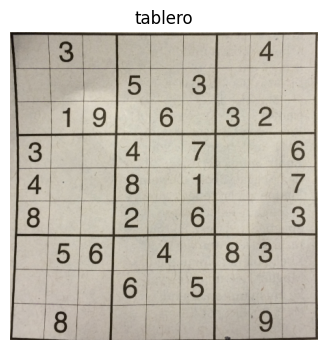

In [7]:
rec = recognizer.DigitRecognizer(weights="../models/digit_cnn.pt", device=DEVICE)
board, cells = crop.to_cells(cv2.imread(test_imgs[0]))
grid = rec.recognize_grid(cells)
print("matriz leida (nuevo modelo):")
for row in grid:
    print(row)
print("\nvalida:", is_valid(rec.recognize(cells)))
plt.figure(figsize=(4, 4)); plt.imshow(cv2.cvtColor(board, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.title("tablero"); plt.show()